In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

medical_data = pd.read_csv('insurance.csv')
# print(medical_data)
# print(medical_data.info())
print(medical_data.smoker.value_counts())

# fig = px.histogram(medical_data, x = 'age', marginal = 'box', nbins = 47, title = 'Distribution of Age')

# fig = px.histogram(medical_data,
             #      x = 'sex',
             #      marginal = 'box',
             #      color = 'region',
             #      color_discrete_sequence = ['green', 'grey'],
             #      title = 'Distribution of Charges')

#fig.update_layout(bargap = 0.1)
# fig.show()

px.histogram(medical_data, x = 'sex', title = 'Sex')
px.histogram(medical_data, x = 'region', color = 'smoker', title = 'Region')
px.histogram(medical_data, x = 'children', color = 'smoker' , title = 'Children')


fig = px.scatter(medical_data, x = 'age', y = 'charges', opacity = 0.8, hover_data = ['sex'], color = 'smoker', title = 'Age vs Charges')
fig.update_traces(marker_size = 6)
fig.show()

fig = px.scatter(medical_data, x = 'bmi', y = 'charges', opacity = 0.8, hover_data = ['sex'], color = 'smoker', title = 'BMI vs Charges')
fig.update_traces(marker_size = 5)
fig.show()

fig = px.scatter(medical_data, x = 'children', y = 'charges', opacity = 0.8, hover_data = ['sex'], color = 'smoker', title = 'Children vs Charges')
fig.update_traces(marker_size = 6)
fig.show()

fig = px.scatter(medical_data, x = 'sex', y = 'charges', opacity = 0.8, hover_data = ['sex'], color = 'smoker', title = 'Sex vs Charges')
fig.update_traces(marker_size = 6)
fig.show()

fig = px.scatter(medical_data, x = 'region', y = 'charges', opacity = 0.8, hover_data = ['sex'], color = 'smoker', title = 'Region vs Charges')
fig.update_traces(marker_size = 6)
fig.show()

fig = px.scatter(medical_data, x = 'smoker', y = 'charges', opacity = 0.8, hover_data = ['sex'], color = 'smoker', title = 'Smoker vs Charges')
fig.update_traces(marker_size = 6)
fig.show()


medical_data.charges.corr(medical_data.age)
medical_data.charges.corr(medical_data.bmi)
medical_data.charges.corr(medical_data.children)

smoker
no     1064
yes     274
Name: count, dtype: int64


np.float64(0.0679982268479048)

<Axes: title={'center': 'Age vs Charges'}, xlabel='age', ylabel='charges'>

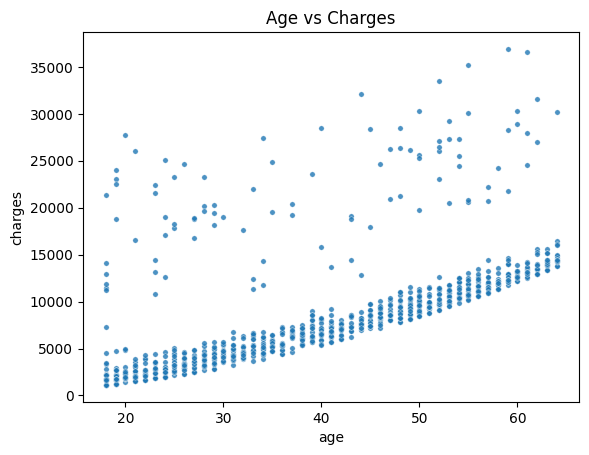

In [9]:
non_smoker = medical_data[medical_data.smoker == 'no']

plt.title('Age vs Charges')
sns.scatterplot(non_smoker, x = 'age', y = 'charges', alpha = 0.8, s = 15)

In [10]:
def estimate_charges(age, m, c):
    return m * age + c

In [11]:
m = 50
c = 100

In [12]:
estimate_charges(40, m, c)

2100

In [13]:
age = non_smoker.age
age

1       18
2       28
3       33
4       32
5       31
        ..
1332    52
1333    50
1334    18
1335    18
1336    21
Name: age, Length: 1064, dtype: int64

In [14]:
estimated_charges = estimate_charges(age, m, c)
estimated_charges

1       1000
2       1500
3       1750
4       1700
5       1650
        ... 
1332    2700
1333    2600
1334    1000
1335    1000
1336    1150
Name: age, Length: 1064, dtype: int64

In [15]:
non_smoker.charges

1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

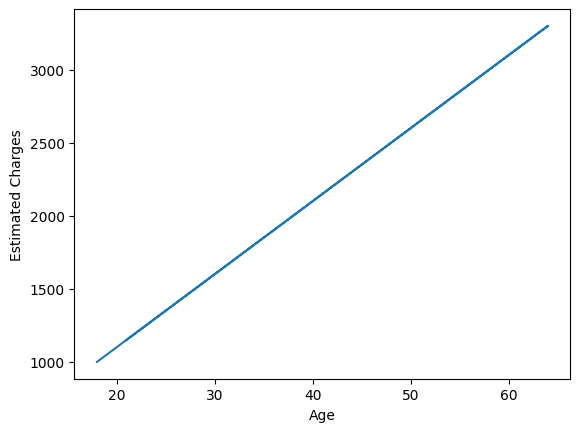

In [16]:
plt.plot(age, estimated_charges);
plt.xlabel('Age');
plt.ylabel('Estimated Charges');

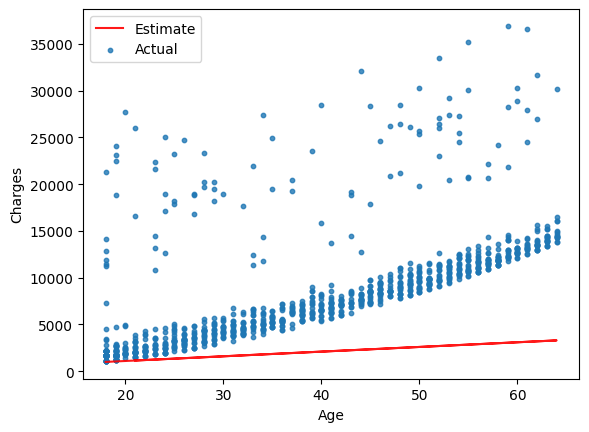

In [17]:
target = non_smoker.charges

plt.plot(age, estimated_charges, 'r', alpha = 0.9);
plt.scatter(age, target, alpha = 0.8, s = 10);
plt.xlabel('Age');
plt.ylabel('Charges');
plt.legend(['Estimate', 'Actual']);

In [18]:
def try_para(m, c):
    age = non_smoker.age
    target = non_smoker.charges

    estimated_charges = estimate_charges(age, m, c)

    plt.plot(age, estimated_charges, 'r', alpha = 0.9);
    plt.scatter(age, target, alpha = 0.8, s = 10);
    plt.xlabel('Age');
    plt.ylabel('Charges');
    plt.legend(['Estimate', 'Actual']);

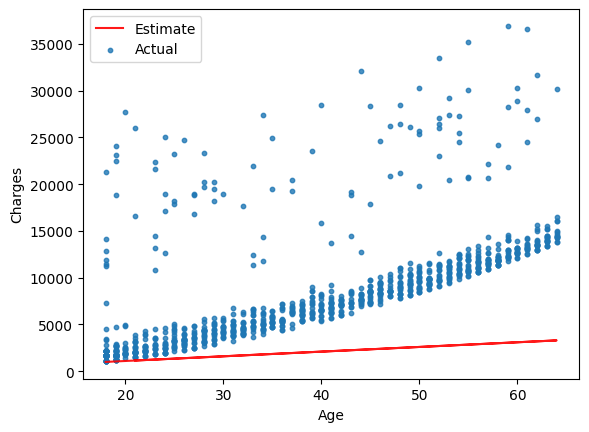

In [19]:
try_para(50, 100)

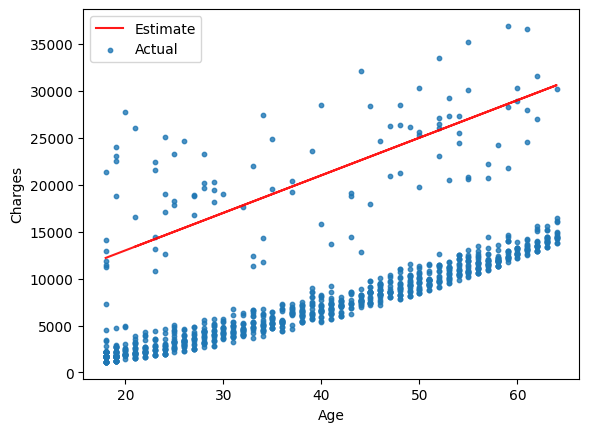

In [20]:
try_para(400, 5000)

In [21]:
import numpy as np


In [22]:
def rmse(target, prediction):
    return np.sqrt(np.mean((target - prediction) ** 2))

In [23]:
m = 50
c = 100

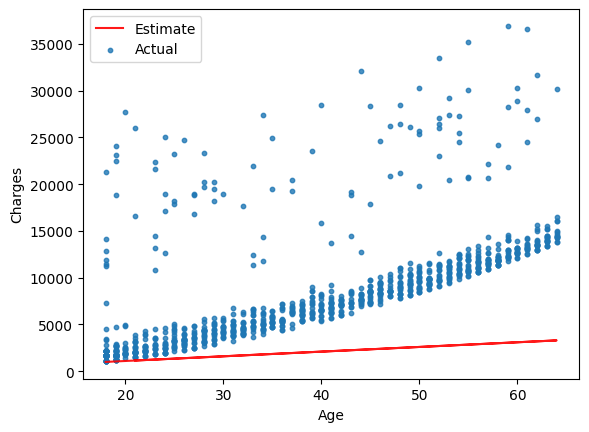

In [24]:
try_para(m, c)

In [25]:
target = non_smoker['charges']
predicted = estimate_charges(non_smoker.age, m, c)

In [26]:
rmse(target, predicted)

np.float64(8461.949562575493)

In [27]:
def try_para(m, c):
    age = non_smoker.age
    target = non_smoker.charges
    predictions = estimate_charges(age, m, c)

    plt.plot(age, predictions, 'r', alpha = 0.9);
    plt.scatter(age, target, alpha = 0.8, s = 10);
    plt.xlabel('Age');
    plt.ylabel('Charges');
    plt.legend(['Prediction', 'Actual']);

    loss = rmse(target, predictions)
    print(f'RMSE LOSS: {loss}')

RMSE LOSS: 4662.516524487403


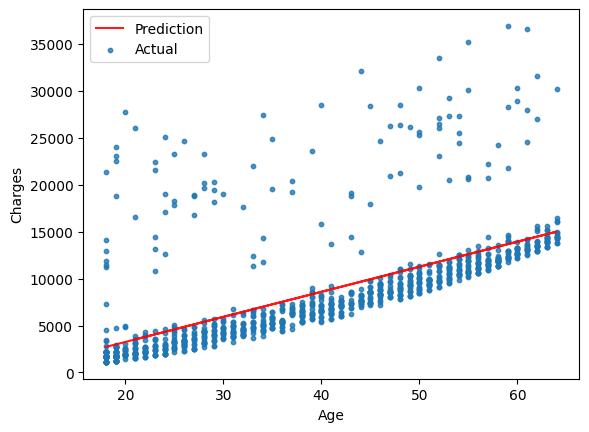

In [31]:
try_para(267, -2091)

In [123]:
!pip3 install scikit-learn --quiet


In [32]:
from sklearn.linear_model import LinearRegression

In [33]:
model = LinearRegression()

In [34]:
inputs = non_smoker[['age']]
targets = non_smoker.charges
print('inputs: ', inputs.shape)
print('targets: ', targets.shape)

inputs:  (1064, 1)
targets:  (1064,)


In [35]:
model.fit(inputs, targets)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
model.predict(np.array([[23],
                        [37],
                        [61]]))

/Users/harshiljodhani/Harshil-Codes/Harshil-PD/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 4055.30443855,  7796.78921819, 14210.76312614])

In [44]:
predictions = model.predict(inputs)
predictions

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289], shape=(1064,))

In [38]:
inputs
targets

1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

In [39]:
rmse(targets, predictions)

np.float64(4662.505766636395)

In [40]:
model.coef_ # m

array([267.24891283])

In [41]:
model.intercept_ # c

np.float64(-2091.4205565650773)

RMSE LOSS: 4662.505766636395


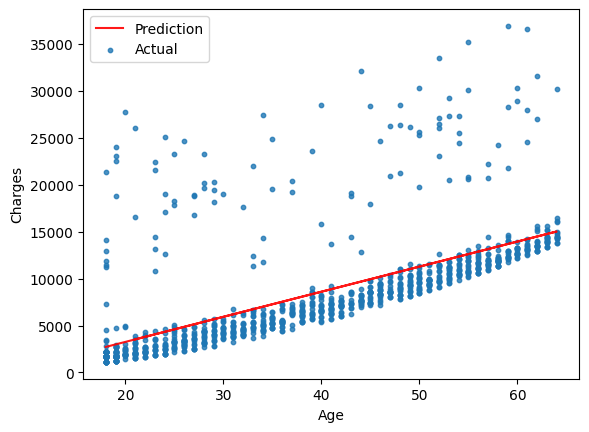

In [42]:
try_para(model.coef_, model.intercept_)

In [52]:
inputs, targets = medical_data[['age', 'bmi', 'children']], medical_data['charges']

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)
predictions

loss = rmse(targets, predictions)
print(f'RMSE Loss: {loss}')

RMSE Loss: 11355.317901125973


In [49]:
model.coef_

array([239.99447429, 332.0833645 , 542.86465225])

In [53]:
model.intercept_

np.float64(-6916.243347787036)

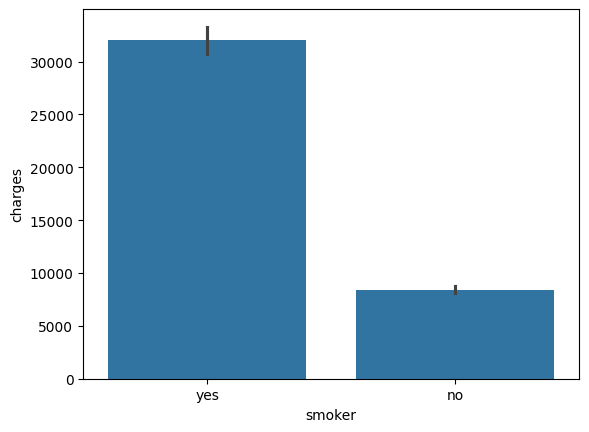

In [55]:
sns.barplot(medical_data, x = 'smoker', y = 'charges');

In [70]:
smoker_code = {'no': 0, 'yes': 1}
medical_data['smoker_code'] = medical_data.smoker.map(smoker_code)
medical_data

,age,sex,bmi,children,smoker,region,charges,smoker_code
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0
1334,18,female,31.920,0,no,northeast,2205.98080,0
1335,18,female,36.850,0,no,southeast,1629.83350,0
1336,21,female,25.800,0,no,southwest,2007.94500,0


In [71]:
medical_data.charges.corr(medical_data.smoker_code)

np.float64(0.7872514304984772)

In [73]:
inputs, targets = medical_data[['age', 'bmi', 'children', 'smoker_code']], medical_data['charges']

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)
predictions

loss = rmse(targets, predictions)
print(f'RMSE Loss: {loss}')

RMSE Loss: 6056.439217188081


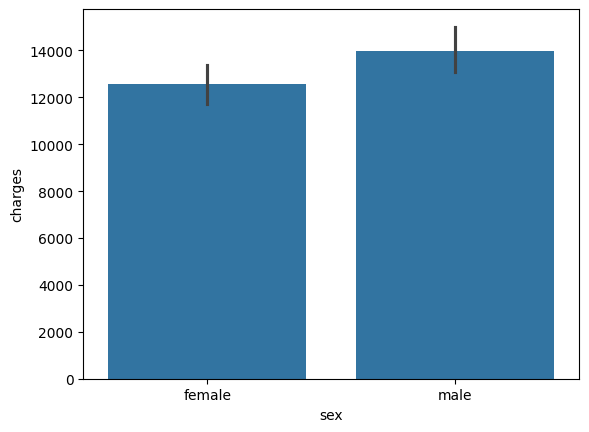

In [77]:
sns.barplot(medical_data, x = 'sex', y = 'charges');

In [78]:
sex_code = {'female': 0, 'male': 1}
medical_data['sex_code'] = medical_data.sex.map(sex_code)
medical_data

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code
0,19,female,27.900,0,yes,southwest,16884.92400,1,0
1,18,male,33.770,1,no,southeast,1725.55230,0,1
2,28,male,33.000,3,no,southeast,4449.46200,0,1
3,33,male,22.705,0,no,northwest,21984.47061,0,1
4,32,male,28.880,0,no,northwest,3866.85520,0,1
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1
1334,18,female,31.920,0,no,northeast,2205.98080,0,0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0


In [79]:
medical_data.charges.corr(medical_data.sex_code)

np.float64(0.057292062202025366)

In [81]:
inputs, targets = medical_data[['age', 'bmi', 'children', 'smoker_code', 'sex_code']], medical_data['charges']

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)
predictions

loss = rmse(targets, predictions)
print(f'RMSE Loss: {loss}')

RMSE Loss: 6056.100708754546


<Axes: xlabel='region', ylabel='charges'>

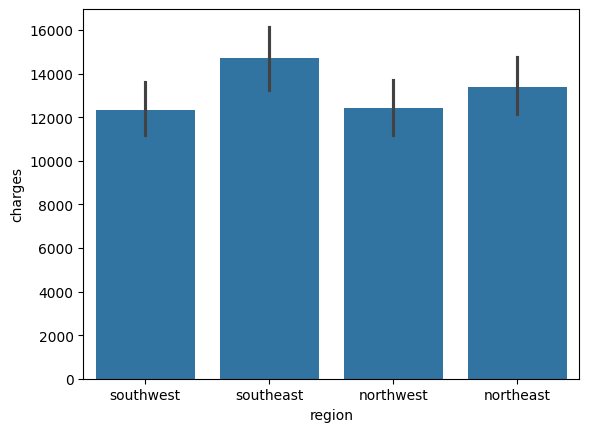

In [82]:
sns.barplot(medical_data, x = 'region', y = 'charges')

In [84]:
from sklearn import preprocessing
enc = preprocessing.OneHotEncoder()
enc.fit(medical_data[['region']])
enc.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [85]:
one_hot = enc.transform(medical_data[['region']]).toarray()
one_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]], shape=(1338, 4))

In [87]:
medical_data[['northwest', 'northeast', 'southwest', 'southeast']] = one_hot
medical_data

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northwest,northeast,southwest,southeast
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


In [91]:
inputs, targets = medical_data[['age', 'bmi', 'children', 'smoker_code', 'northwest', 'northeast', 'southwest', 'southeast']], medical_data['charges']

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)
predictions

loss = rmse(targets, predictions)
print(f'RMSE Loss: {loss}')

RMSE Loss: 6042.033215394104


In [96]:
medical_data

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northwest,northeast,southwest,southeast
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


In [97]:
from sklearn.preprocessing import StandardScaler

In [99]:
numeric_cols = ['age', 'bmi', 'children']
scaler = StandardScaler()
scaler.fit(medical_data[numeric_cols])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [100]:
scaler.mean_

array([39.20702541, 30.66339686,  1.09491779])

In [104]:
scaler.var_

array([197.25385199,  37.16008997,   1.45212664])

In [105]:
scaled_inputs = scaler.transform(medical_data[numeric_cols])
scaled_inputs

array([[-1.43876426, -0.45332   , -0.90861367],
       [-1.50996545,  0.5096211 , -0.07876719],
       [-0.79795355,  0.38330685,  1.58092576],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367],
       [-1.29636188, -0.79781341, -0.90861367],
       [ 1.55168573, -0.26138796, -0.90861367]], shape=(1338, 3))

In [107]:
cat_cols = ['smoker_code', 'northwest', 'northeast', 'southwest', 'southeast']
categorical_inputs = medical_data[cat_cols].values
categorical_inputs

array([[1., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       ...,
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.],
       [1., 0., 1., 0., 0.]], shape=(1338, 5))

In [110]:
inputs = np.concatenate((scaled_inputs, categorical_inputs), axis=1)
targets = medical_data.charges

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)

loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6042.033215394104
